In [55]:

import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

In [56]:
# 1. Definição estrita do modelo físico vetorial
def modelo_gaussiano(x, amplitude, centro, largura, fundo):
    return amplitude * np.exp(-((x - centro)**2) / (2 * largura**2)) + fundo

In [57]:
# 2. Geração de dados de teste
np.random.seed(45)
x_dados = np.linspace(4600, 4760, 150)
y_puro = modelo_gaussiano(x_dados,100,4680,10,15)
y_ruido = y_puro + np.random.normal(0, 5, len(x_dados))


In [58]:
# 3. O Ajuste 
chute_inicial = [100, 4680, 10, 15]
parametros_otimizados, matriz_covariancia = curve_fit(modelo_gaussiano, x_dados, y_ruido, p0=chute_inicial)

In [59]:
# 4. Cálculo dos resíduos 
y_ajustado = modelo_gaussiano(x_dados, *parametros_otimizados) 
residuos = y_ruido - y_ajustado

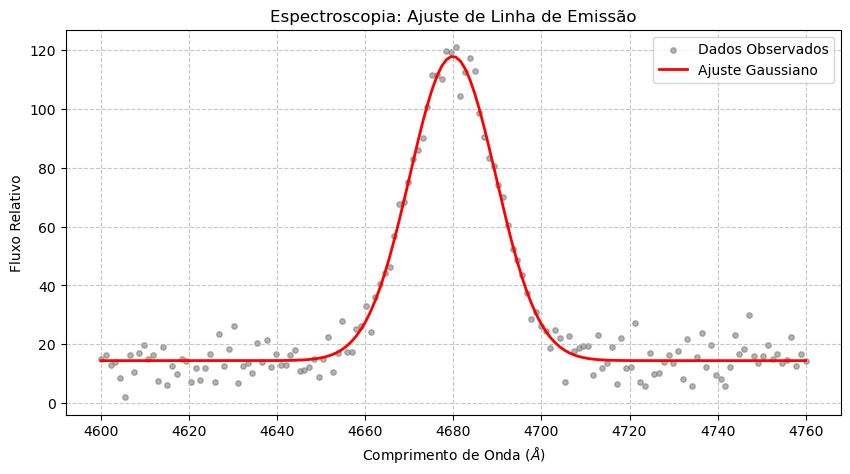

In [60]:
# 5. Visualização Científica
plt.figure(figsize=(10, 5))
plt.scatter(x_dados, y_ruido, label='Dados Observados', color='gray', alpha=0.6 , s=15) 
plt.plot(x_dados, y_ajustado, label='Ajuste Gaussiano', color='red', linewidth=2)
plt.title("Espectroscopia: Ajuste de Linha de Emissão") 
plt.xlabel("Comprimento de Onda ($\AA$)") 
plt.ylabel("Fluxo Relativo")
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()